0. Preliminaries

In [1]:
import Pkg; Pkg.add("BenchmarkTools")

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


In [2]:
import Pkg; Pkg.add("Revise")

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


In [3]:
import Pkg; Pkg.add("BifurcationKit")

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


In [4]:
import Pkg; Pkg.add(url="https://github.com/johnfgibson/CloudAtlas.jl")

    Updating git-repo `https://github.com/johnfgibson/CloudAtlas.jl`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


In [5]:
using LinearAlgebra, Polynomials, Plots, DelimitedFiles, BenchmarkTools, Revise
import BifurcationKit as BK

using CloudAtlas

#display("text/html", "")

"""
    myreaddlm(filename, cc='%')

Read matrix or vector from a file, dropping comments marked with cc.
"""
function myreaddlm(filename; cc='%')
    X = readdlm(filename, comments=true, comment_char=cc)
    if size(X,2) == 1
        X = X[:,1]
    end
    X
end

sx, sy, sz, tx, tz = halfbox_symmetries()       #performs a set of flips in s, and translations in t


pwd()

"/Users/samgeho/Downloads"

1. Construct ODE model, find equilibrium solution.

In [21]:
#α, γ = 1.0, 2.0
#store = [5][1:3]
α, γ = store[5][1], store[5][2]                    # Fourier wavenumbers α, γ = 2π/Lx, 2π/Lz
J,K,L = 1,2,3                       # Bounds on Fourier modes (J,K) and wall-normal polynomials (L)
H = [sx*sy*sz, sz*tx*tz]          # Generators of the symmetric subspace of the Nagata eqb
println(H)

model = ODEModel(α, γ, J, K, L, H)  # Construct ODE model by Galerkin projection 

@show m = length(model);            # dimension of ODE model

Symmetry[Symmetry(-1, -1, -1, 0//1, 0//1, 1), Symmetry(1, 1, -1, 1//2, 1//2, 1)]
J,K,L,m == 1,2,3,27
(2J+1)(2K+1)(2L+1) + 1 == 106
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 
m = length(model) = 27


In [22]:
xguess = myreaddlm("/Users/samgeho/Desktop/TECH 412/xeq1projection-Re200-1-2-3-27d.asc")
#xguess = store[5][3]
R = 200
@show norm(model.f(xguess, R));

norm(model.f(xguess, R)) = 0.010075483841949067


In [23]:
fr = x -> model.f(x,R)    # define function  f(x) = f(x,R)  for fixed R
Dfr = x -> model.Df(x,R)  # define function Df(x) = Df(x,R) for fixed R

@time xeq1, eq1success = hookstepsolve(fr, Dfr, xguess)

@show norm(fr(xeq1))/norm(xeq1);

  0.052468 seconds (83.53 k allocations: 6.417 MiB, 96.95% compilation time)
norm(fr(xeq1)) / norm(xeq1) = 3.497537637156571e-9


2. Continuation of eqbs with BifurcationKit

In [24]:
shear(xeq1, model)

1.5398403467246013

In [25]:
myshear = x -> shear(x,model) ###one with fixed basis I=myshear(xeq1)
myshear(xeq1)

1.5398403467246013

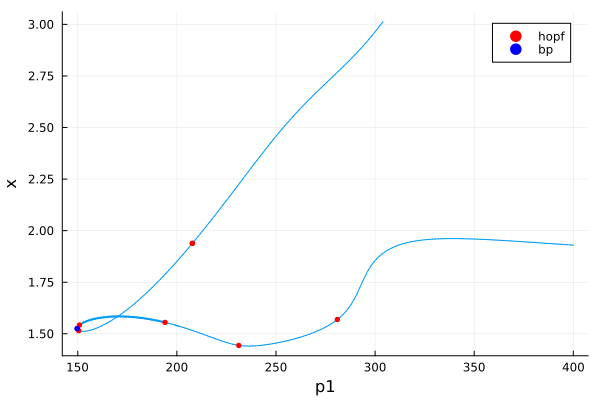

In [26]:
fp(x,p) = model.f(x,p[1])
prob1 = BK.BifurcationProblem(fp,
        xeq1,         # initial condition x0
        [Float64(R)], # set of parameters
        1;            # parameter index for continuation
        #record_from_solution = (x,p; k...) -> shear(x),
        plot_solution = (x,p; k...) -> myshear(x),
        record_from_solution = (x,p; k...) -> myshear(x),
    )

newtopts = BK.NewtonPar(1e-10, 25, false, BK.DefaultLS(), BK.DefaultEig(), false, 1.0, 0.01)
contopts = BK.ContinuationPar(p_min = 100., p_max = 400., n_inversion=20, dsmin=1e-12, dsmax=1.0, 
    max_steps = 200, newton_options = newtopts)

br1 = BK.continuation(prob1, BK.PALC(), contopts, bothside=true)

plot(br1)
#println(α)
#println(γ)

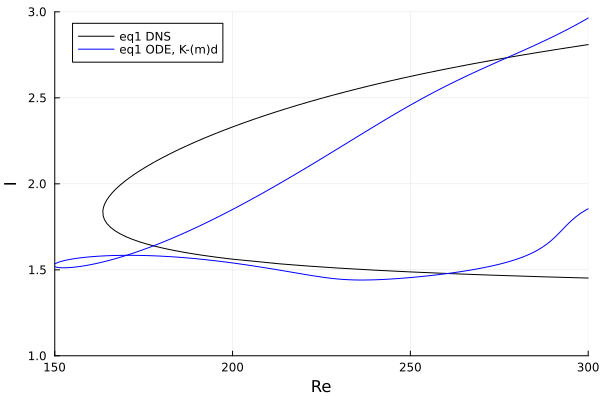

In [27]:
ReD1 = [br1.param br1.x];

eq1ReD = myreaddlm("/Users/samgeho/Desktop/TECH 412/eq1ReD-DNS.asc", cc='#')
plot(eq1ReD[:,1], eq1ReD[:,2], color=:black, label="eq1 DNS")
plot!(ReD1[:,1], ReD1[:,2], color=:blue, label="eq1 ODE, K-(m)d")
#plot!(ReD2[:,1], ReD2[:,2], color=:blue, label="")
plot!(xlabel="Re", ylabel="I", xlim=(150,300), ylim=(1,3))     

my_matrix = [R, α, γ, xguess] = Any[200, 0.9, 1.8, [0.1057562233477614, -0.053953381733575084, 0.3882673617361376, -0.017271618528877614, -0.013280389303813082, 0.011256311213268288, 0.01244439528778787, -0.017975383550434907, 0.0028606406132429436, -0.007062219235032701, 0.0239626366017236, -0.03441234734494484, -0.008683149078727411, -0.012644472501429522, 0.002547120403848012, -0.002651045251033871, -0.001294807530986317, -0.0035670156564768475, -0.023425228121848714, -0.03197420527401155, -0.017992034721883737, -0.004642245352151625, 0.010572383149277687, 0.02348270359960592, -0.007331722175024302, -0.007994514969769193, -0.0010385283210509282]]
plotData = [] = Any[]
J,K,L,m == 1,2,3,27
(2J+1)(2K+1)(2L+1) + 1 == 106
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 
norm(model.f(xguess, R)) = 0.00952405613492764
  0.056121 seconds (82.22 k allocations: 5.123 MiB, 98.02% compilation time)
norm(fr(xeq1

26-element Vector{Float64}:
  9.848957833531765e-5
 47.02160377810786
 11.755328776542767
  2.939654095431829
  0.7340979323008449
  0.1841142952046361
  0.045228598494546156
  0.020798439287154812
  0.1110573886401519
  0.6966410165385962
  ⋮
  3.64934655154375
  1.0671458990793243
  1.0224378848159585
  1.3259351570932805
  0.3685393979421529
  2.913780897261976
  2.7767396219280487
  3.0236971225829143
  1.0788373090512917

26-element Vector{Float64}:
  0.0003098359772101276
 11.772803047934062
  2.9408283161172992
  0.737274576663703
  0.1847537472206544
  0.044258217223697195
  0.043867355921899984
  0.7633799675093905
  0.19700657173565428
  0.0968755129283572
  ⋮
  0.28724419512415916
  0.14941819837328207
 14.43353672093878
  3.5864978393205122
  0.8544069122392303
  0.793885167839562
  0.39201038878451927
  2.2313914953024714
  0.561817104324069

26-element Vector{Float64}:
    0.0004948417461763004
  111.60656004018153
   27.90177074132284
    6.975927921190702
    1.7508399310260636
    0.45451208141382615
    0.11280930334644755
    0.759600066432954
    0.1838210103607957
    0.2503323444359761
    ⋮
    0.21032475347120605
    2.4248776178202798
    9.015754525581606
    2.440207588851243
    1.470699569902261
    4.411443039292911
 1564.2408541105453
  391.58050703697916
   98.2804835850762

26-element Vector{Float64}:
    0.0006539840724262722
 2121.6234596011063
  530.4058960782829
  132.60155060328046
   33.15054995868429
    8.28801064276757
    2.0790045606443215
    0.5122399001445861
    0.12953114141490343
    0.040151061237620855
    ⋮
    0.10119099895416371
    0.043177308384586915
    0.15915271597330827
    2.770898420720442
    0.7061335209977011
    0.18238346731179658
    0.9413372157461727
    0.2827785764005076
    4.882167417838431

26-element Vector{Float64}:
   0.0007876621947393536
 290.9005011214322
  72.72532211905414
  18.18055011709113
   4.544632326807063
   1.1348567932324727
   0.6995628301171575
   0.15196809944719156
   0.07218025560141593
   0.029233590999537564
   ⋮
   0.8442655950875761
   0.2017110621341732
   0.33469409896794783
   1.1968872669641315
   0.26847933723388745
   0.23579031335628767
   1.2917251368073663
  21.51536856513423
   5.322160972828101

26-element Vector{Float64}:
 0.00014508505260962302
 0.8495958520425319
 0.21217090315866716
 0.05176387298287885
 0.016898658044902162
 0.0051176308143427275
 0.0015134760981381599
 0.009738622154291962
 0.002581769251439052
 0.0010801266941663748
 ⋮
 0.0010889298034088128
 0.005473389089727334
 0.0016873483393875064
 0.0010907289823237458
 0.005315005116916542
 0.0016499840746552706
 0.0011063007840451948
 0.004277531321907566
 0.00141062447614888

26-element Vector{Float64}:
   0.0006429134030277799
   5.949607074944819
   1.4872450505554606
   0.3714331224914768
   0.08619894440021297
  88.92699112823989
  22.231254167946627
   5.556637173214367
   1.377010651127794
   0.4351192353521093
   ⋮
   2.4606450011356165
   1.0572821431283908
  13.112138526382873
  22.963369895875008
 124.42654636786038
  32.1285213519385
  10.786885670967514
   3.963387851247128
   6.744815925333909

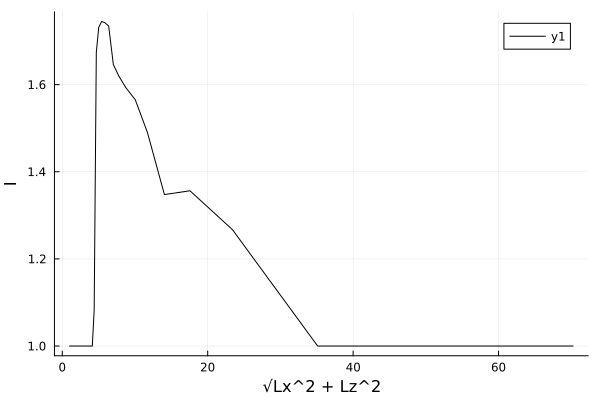

In [28]:
α, γ = 0.9, 1.8         # Fourier wavenumbers α, γ = 2π/Lx, 2π/Lz

xguess = myreaddlm("/Users/samgeho/Desktop/TECH 412/xeq1projection-Re200-1-2-3-27d.asc")

R = 200


α, γ = 0.9, 1.8  
    
#@show norm(model.f(xguess, R));
norm(model.f(xguess, R));

fr = x -> model.f(x,R)    # define function  f(x) = f(x,R)  for fixed R
Dfr = x -> model.Df(x,R)  # define function Df(x) = Df(x,R) for fixed R

#@time xeq1, eq1success = hookstepsolve(fr, Dfr, xguess)
xeq1, eq1success = hookstepsolve(fr, Dfr, xguess)

#@show norm(fr(xeq1))/norm(xeq1);
norm(fr(xeq1))/norm(xeq1);

shear(xeq1, model)

myshear = x -> shear(x,model) ###one with fixed basis I=myshear(xeq1)
myshear(xeq1)

@show my_matrix = [R, α, γ, xguess]
@show plotData = []

   
for i in 0:0.1:6                 
    
    try
        α += 0.1
        γ += 0.2
        J,K,L = 1,2,3  #1,2,3  #1,1,3       # Bounds on Fourier modes (J,K) and wall-normal polynomials (L)
        H = [sx*sy*sz, sz*tx*tz]            # Generators of the symmetric subspace of the Nagata eqb
    
        model = ODEModel(α, γ, J, K, L, H)  # Construct ODE model by Galerkin projection 
    
        #@show m = length(model)
        #@show x = length(xguess)
        @show norm(model.f(xguess, R));
    
        fr = x -> model.f(x,R)    # define function  f(x) = f(x,R)  for fixed R
        Dfr = x -> model.Df(x,R)  # define function Df(x) = Df(x,R) for fixed R
    
        @time xeq1, eq1success = hookstepsolve(fr, Dfr, xguess)
    
        
        @show norm(fr(xeq1))/norm(xeq1);
    
        shear(xeq1, model)
    
        myshear = x -> shear(x,model) ###one with fixed basis I=myshear(xeq1)
        I = myshear(xeq1)
        push!(plotData, [sqrt((2*pi/α)^2 + (2*pi/γ)^2), I])
        fp(x,p) = model.f(x,p[1])
        prob1 = BK.BifurcationProblem(fp,
            xeq1,         # initial condition x0
            [Float64(R)], # set of parameters
            1;            # parameter index for continuation
            #record_from_solution = (x,p; k...) -> shear(x),
            plot_solution = (x,p; k...) -> myshear(x),
            record_from_solution = (x,p; k...) -> myshear(x),
            )
    
        newtopts = BK.NewtonPar(1e-10, 25, false, BK.DefaultLS(), BK.DefaultEig(), false, 1.0, 0.01)
        contopts = BK.ContinuationPar(p_min = 100., p_max = 400., n_inversion=20, dsmin=1e-07, dsmax=1.0, 
            max_steps = 200, newton_options = newtopts)
        
        br1 = BK.continuation(prob1, BK.PALC(), contopts, bothside=true)
        
        plot(br1)
           
        global xguess = xeq1
    
        push!(my_matrix, [R, α, γ, xguess])
    catch e
    end
end

α, γ = 1.1, 2.2         # Fourier wavenumbers α, γ = 2π/Lx, 2π/Lz

xguess = myreaddlm("/Users/samgeho/Desktop/TECH 412/xeq1projection-Re200-1-2-3-27d.asc")

for i in 0:0.1:0.9                 
    
    try
        α -= 0.1
        γ -= 0.2
        J,K,L = 1,2,3  #1,2,3  #1,1,3       # Bounds on Fourier modes (J,K) and wall-normal polynomials (L)
        H = [sx*sy*sz, sz*tx*tz]            # Generators of the symmetric subspace of the Nagata eqb
    
        model = ODEModel(α, γ, J, K, L, H)  # Construct ODE model by Galerkin projection 
    
        #@show m = length(model)
        #@show x = length(xguess)
        @show norm(model.f(xguess, R));
    
        fr = x -> model.f(x,R)    # define function  f(x) = f(x,R)  for fixed R
        Dfr = x -> model.Df(x,R)  # define function Df(x) = Df(x,R) for fixed R
    
        @time xeq1, eq1success = hookstepsolve(fr, Dfr, xguess)
    
        
        @show norm(fr(xeq1))/norm(xeq1);
    
        shear(xeq1, model)
    
        myshear = x -> shear(x,model) ###one with fixed basis I=myshear(xeq1)
        I = myshear(xeq1)
        pushfirst!(plotData, [sqrt((2*pi/α)^2 + (2*pi/γ)^2), I])
        fp(x,p) = model.f(x,p[1])
        prob1 = BK.BifurcationProblem(fp,
            xeq1,         # initial condition x0
            [Float64(R)], # set of parameters
            1;            # parameter index for continuation
            #record_from_solution = (x,p; k...) -> shear(x),
            plot_solution = (x,p; k...) -> myshear(x),
            record_from_solution = (x,p; k...) -> myshear(x),
            )
    
        newtopts = BK.NewtonPar(1e-10, 25, false, BK.DefaultLS(), BK.DefaultEig(), false, 1.0, 0.01)
        contopts = BK.ContinuationPar(p_min = 100., p_max = 400., n_inversion=20, dsmin=1e-07, dsmax=1.0, 
            max_steps = 200, newton_options = newtopts)
        
        br1 = BK.continuation(prob1, BK.PALC(), contopts, bothside=true)
        
        plot(br1)
           
        global xguess = xeq1
    
        push!(my_matrix, [R, α, γ, xguess])
    catch e
    end
end

    
plot(getindex.(plotData, 1), getindex.(plotData, 2), color=:black, xlabel = "√Lx^2 + Lz^2", ylabel = "I")
#display(my_matrix)
#display(plotData)

#=
ReD1 = [br1.param br1.x];

eq1ReD = myreaddlm("desktop/TECH 412/eq1ReD-DNS.asc", cc='#')
plot(eq1ReD[:,1], eq1ReD[:,2], color=:black, label="eq1 DNS")
plot!(ReD1[:,1], ReD1[:,2], color=:blue, label="eq1 ODE, K-(m)d")
#plot!(ReD2[:,1], ReD2[:,2], color=:blue, label="")
plot!(xlabel="Re", ylabel="I", xlim=(150,300), ylim=(1,3))    
=#

**#### Contour Graph!**

my_matrix = [R, α, γ, xguess] = Any[200, 0.9, 1.8, [0.1057562233477614, -0.053953381733575084, 0.3882673617361376, -0.017271618528877614, -0.013280389303813082, 0.011256311213268288, 0.01244439528778787, -0.017975383550434907, 0.0028606406132429436, -0.007062219235032701, 0.0239626366017236, -0.03441234734494484, -0.008683149078727411, -0.012644472501429522, 0.002547120403848012, -0.002651045251033871, -0.001294807530986317, -0.0035670156564768475, -0.023425228121848714, -0.03197420527401155, -0.017992034721883737, -0.004642245352151625, 0.010572383149277687, 0.02348270359960592, -0.007331722175024302, -0.007994514969769193, -0.0010385283210509282]]
plotData = [] = Any[]
J,K,L,m == 1,2,3,27
(2J+1)(2K+1)(2L+1) + 1 == 106
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 
norm(model.f(xguess, R)) = 0.00952405613492764
  0.058835 seconds (82.19 k allocations: 5.119 MiB, 98.18% compilation time)
norm(fr(xeq1

26-element Vector{Float64}:
  9.848957833531765e-5
 47.02160377810786
 11.755328776542767
  2.939654095431829
  0.7340979323008449
  0.1841142952046361
  0.045228598494546156
  0.020798439287154812
  0.1110573886401519
  0.6966410165385962
  ⋮
  3.64934655154375
  1.0671458990793243
  1.0224378848159585
  1.3259351570932805
  0.3685393979421529
  2.913780897261976
  2.7767396219280487
  3.0236971225829143
  1.0788373090512917

26-element Vector{Float64}:
  0.0003098359772101276
 11.772803047934062
  2.9408283161172992
  0.737274576663703
  0.1847537472206544
  0.044258217223697195
  0.043867355921899984
  0.7633799675093905
  0.19700657173565428
  0.0968755129283572
  ⋮
  0.28724419512415916
  0.14941819837328207
 14.43353672093878
  3.5864978393205122
  0.8544069122392303
  0.793885167839562
  0.39201038878451927
  2.2313914953024714
  0.561817104324069

26-element Vector{Float64}:
    0.0004948417461763004
  111.60656004018153
   27.90177074132284
    6.975927921190702
    1.7508399310260636
    0.45451208141382615
    0.11280930334644755
    0.759600066432954
    0.1838210103607957
    0.2503323444359761
    ⋮
    0.21032475347120605
    2.4248776178202798
    9.015754525581606
    2.440207588851243
    1.470699569902261
    4.411443039292911
 1564.2408541105453
  391.58050703697916
   98.2804835850762

26-element Vector{Float64}:
    0.0006539840724262722
 2121.6234596011063
  530.4058960782829
  132.60155060328046
   33.15054995868429
    8.28801064276757
    2.0790045606443215
    0.5122399001445861
    0.12953114141490343
    0.040151061237620855
    ⋮
    0.10119099895416371
    0.043177308384586915
    0.15915271597330827
    2.770898420720442
    0.7061335209977011
    0.18238346731179658
    0.9413372157461727
    0.2827785764005076
    4.882167417838431

26-element Vector{Float64}:
   0.0007876621947393536
 290.9005011214322
  72.72532211905414
  18.18055011709113
   4.544632326807063
   1.1348567932324727
   0.6995628301171575
   0.15196809944719156
   0.07218025560141593
   0.029233590999537564
   ⋮
   0.8442655950875761
   0.2017110621341732
   0.33469409896794783
   1.1968872669641315
   0.26847933723388745
   0.23579031335628767
   1.2917251368073663
  21.51536856513423
   5.322160972828101

26-element Vector{Float64}:
 0.00014508505260962302
 0.8495958520425319
 0.21217090315866716
 0.05176387298287885
 0.016898658044902162
 0.0051176308143427275
 0.0015134760981381599
 0.009738622154291962
 0.002581769251439052
 0.0010801266941663748
 ⋮
 0.0010889298034088128
 0.005473389089727334
 0.0016873483393875064
 0.0010907289823237458
 0.005315005116916542
 0.0016499840746552706
 0.0011063007840451948
 0.004277531321907566
 0.00141062447614888

26-element Vector{Float64}:
   0.0006429134030277799
   5.949607074944819
   1.4872450505554606
   0.3714331224914768
   0.08619894440021297
  88.92699112823989
  22.231254167946627
   5.556637173214367
   1.377010651127794
   0.4351192353521093
   ⋮
   2.4606450011356165
   1.0572821431283908
  13.112138526382873
  22.963369895875008
 124.42654636786038
  32.1285213519385
  10.786885670967514
   3.963387851247128
   6.744815925333909

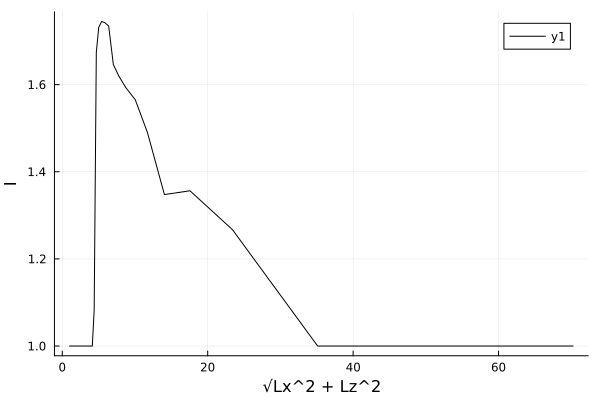

In [29]:
α, γ = 0.9, 1.8         # Fourier wavenumbers α, γ = 2π/Lx, 2π/Lz

xguess = myreaddlm("/Users/samgeho/Desktop/TECH 412/xeq1projection-Re200-1-2-3-27d.asc")

R = 200


α, γ = 0.9, 1.8  
    
#@show norm(model.f(xguess, R));
norm(model.f(xguess, R));

fr = x -> model.f(x,R)    # define function  f(x) = f(x,R)  for fixed R
Dfr = x -> model.Df(x,R)  # define function Df(x) = Df(x,R) for fixed R

#@time xeq1, eq1success = hookstepsolve(fr, Dfr, xguess)
xeq1, eq1success = hookstepsolve(fr, Dfr, xguess)

#@show norm(fr(xeq1))/norm(xeq1);
norm(fr(xeq1))/norm(xeq1);

shear(xeq1, model)

myshear = x -> shear(x,model) ###one with fixed basis I=myshear(xeq1)
myshear(xeq1)

@show my_matrix = [R, α, γ, xguess]
@show plotData = []

   
for i in 0:0.1:6                 
    
    try
        α += 0.1
            γ += 0.2
            J,K,L = 1,2,3  #1,2,3  #1,1,3       # Bounds on Fourier modes (J,K) and wall-normal polynomials (L)
            H = [sx*sy*sz, sz*tx*tz]            # Generators of the symmetric subspace of the Nagata eqb
        
            model = ODEModel(α, γ, J, K, L, H)  # Construct ODE model by Galerkin projection 
        
            #@show m = length(model)
            #@show x = length(xguess)
            @show norm(model.f(xguess, R));
        
            fr = x -> model.f(x,R)    # define function  f(x) = f(x,R)  for fixed R
            Dfr = x -> model.Df(x,R)  # define function Df(x) = Df(x,R) for fixed R
        
            @time xeq1, eq1success = hookstepsolve(fr, Dfr, xguess)
        
            
            @show norm(fr(xeq1))/norm(xeq1);
        
            shear(xeq1, model)
        
            myshear = x -> shear(x,model) ###one with fixed basis I=myshear(xeq1)
            I = myshear(xeq1)
            push!(plotData, [sqrt((2*pi/α)^2 + (2*pi/γ)^2), I])
            fp(x,p) = model.f(x,p[1])
            prob1 = BK.BifurcationProblem(fp,
                xeq1,         # initial condition x0
                [Float64(R)], # set of parameters
                1;            # parameter index for continuation
                #record_from_solution = (x,p; k...) -> shear(x),
                plot_solution = (x,p; k...) -> myshear(x),
                record_from_solution = (x,p; k...) -> myshear(x),
                )
        
            newtopts = BK.NewtonPar(1e-10, 25, false, BK.DefaultLS(), BK.DefaultEig(), false, 1.0, 0.01)
            contopts = BK.ContinuationPar(p_min = 100., p_max = 400., n_inversion=20, dsmin=1e-07, dsmax=1.0, 
                max_steps = 200, newton_options = newtopts)
            
            br1 = BK.continuation(prob1, BK.PALC(), contopts, bothside=true)
            
            plot(br1)
            
            global xguess = xeq1
        
            push!(my_matrix, [R, α, γ, xguess])
    catch e
    end
end

α, γ = 1.1, 2.2         # Fourier wavenumbers α, γ = 2π/Lx, 2π/Lz

xguess = myreaddlm("/Users/samgeho/Desktop/TECH 412/xeq1projection-Re200-1-2-3-27d.asc")

for i in 0:0.1:0.9                 
    
    try
        α -= 0.1
        γ -= 0.2
        J,K,L = 1,2,3  #1,2,3  #1,1,3       # Bounds on Fourier modes (J,K) and wall-normal polynomials (L)
        H = [sx*sy*sz, sz*tx*tz]            # Generators of the symmetric subspace of the Nagata eqb
    
        model = ODEModel(α, γ, J, K, L, H)  # Construct ODE model by Galerkin projection 
    
        #@show m = length(model)
        #@show x = length(xguess)
        @show norm(model.f(xguess, R));
    
        fr = x -> model.f(x,R)    # define function  f(x) = f(x,R)  for fixed R
        Dfr = x -> model.Df(x,R)  # define function Df(x) = Df(x,R) for fixed R
    
        @time xeq1, eq1success = hookstepsolve(fr, Dfr, xguess)
    
        
        @show norm(fr(xeq1))/norm(xeq1);
    
        shear(xeq1, model)
    
        myshear = x -> shear(x,model) ###one with fixed basis I=myshear(xeq1)
        I = myshear(xeq1)
        pushfirst!(plotData, [sqrt((2*pi/α)^2 + (2*pi/γ)^2), I])
        fp(x,p) = model.f(x,p[1])
        prob1 = BK.BifurcationProblem(fp,
            xeq1,         # initial condition x0
            [Float64(R)], # set of parameters
            1;            # parameter index for continuation
            #record_from_solution = (x,p; k...) -> shear(x),
            plot_solution = (x,p; k...) -> myshear(x),
            record_from_solution = (x,p; k...) -> myshear(x),
            )
    
        newtopts = BK.NewtonPar(1e-10, 25, false, BK.DefaultLS(), BK.DefaultEig(), false, 1.0, 0.01)
        contopts = BK.ContinuationPar(p_min = 100., p_max = 400., n_inversion=20, dsmin=1e-07, dsmax=1.0, 
            max_steps = 200, newton_options = newtopts)
        
        br1 = BK.continuation(prob1, BK.PALC(), contopts, bothside=true)
        
        plot(br1)
           
        global xguess = xeq1
    
        push!(my_matrix, [R, α, γ, xguess])
    catch e
    end
end

    
plot(getindex.(plotData, 1), getindex.(plotData, 2), color=:black, xlabel = "√Lx^2 + Lz^2", ylabel = "I")
#display(my_matrix)
#display(plotData)

#=
ReD1 = [br1.param br1.x];

eq1ReD = myreaddlm("desktop/TECH 412/eq1ReD-DNS.asc", cc='#')
plot(eq1ReD[:,1], eq1ReD[:,2], color=:black, label="eq1 DNS")
plot!(ReD1[:,1], ReD1[:,2], color=:blue, label="eq1 ODE, K-(m)d")
#plot!(ReD2[:,1], ReD2[:,2], color=:blue, label="")
plot!(xlabel="Re", ylabel="I", xlim=(150,300), ylim=(1,3))    
=#

J,K,L,m == 1,2,3,27
(2J+1)(2K+1)(2L+1) + 1 == 106
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 
norm(model.f(xguess, R)) = 0.009482757127376803
  0.050397 seconds (82.14 k allocations: 4.949 MiB, 97.47% compilation time)
0.2693793183015427
norm(fr(xeq1)) / norm(xeq1) = 7.505836570565379e-9
J,K,L,m == 1,2,3,27
(2J+1)(2K+1)(2L+1) + 1 == 106
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 
norm(model.f(xguess, R)) = 0.0012253336916900057
  0.000490 seconds (502 allocations: 281.531 KiB)
0.272133781364766
norm(fr(xeq1)) / norm(xeq1) = 8.368135723538921e-9
J,K,L,m == 1,2,3,27
(2J+1)(2K+1)(2L+1) + 1 == 106
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 
norm(model.f(xguess, R)) = 0.0013208665542668802
  0.000449 seconds (502 allocations:

26-element Vector{Float64}:
 6.556178420997734e-5
 0.3042563705712261
 0.07626603045733481
 0.018989903833055658
 0.004869301844690836
 0.0014455285836119968
 0.0005695354773446291
 0.0029053962337255335
 0.0008939709387855322
 0.0005732510286654157
 ⋮
 0.00526470423028373
 0.0014682985708240573
 0.0005840327772198623
 0.0022100126843328915
 0.0007335484089961459
 0.0007151663489244568
 0.0007533980891817292
 0.0006823846392386754
 0.0008501152141696972

┌ Error: Failure to converge with given tolerance = 1.0e-10.
│ Step = 192
│ You can decrease the tolerance or pass a different norm using the argument `normC`.
│ We reached the smallest value [dsmin] valid for ds, namely 1.0e-12.
│ Stopping continuation at continuation step 192.
└ @ BifurcationKit /Users/samgeho/.julia/packages/BifurcationKit/q52qN/src/continuation/Contbase.jl:70


J,K,L,m == 1,2,3,27
(2J+1)(2K+1)(2L+1) + 1 == 106
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 
norm(model.f(xguess, R)) = 0.02650665869568189
  0.003886 seconds (7.77 k allocations: 7.376 MiB)
0.27036026578388517
norm(fr(xeq1)) / norm(xeq1) = 0.0009761320071714748


┌ Error: Failure to converge with given tolerance = 1.0e-10.
│ Step = 168
│ You can decrease the tolerance or pass a different norm using the argument `normC`.
│ We reached the smallest value [dsmin] valid for ds, namely 1.0e-12.
│ Stopping continuation at continuation step 168.
└ @ BifurcationKit /Users/samgeho/.julia/packages/BifurcationKit/q52qN/src/continuation/Contbase.jl:70


...

┌ Error: Failure to converge with given tolerance = 1.0e-10.
│ Step = 168
│ You can decrease the tolerance or pass a different norm using the argument `normC`.
│ We reached the smallest value [dsmin] valid for ds, namely 1.0e-12.
│ Stopping continuation at continuation step 168.
└ @ BifurcationKit /Users/samgeho/.julia/packages/BifurcationKit/q52qN/src/continuation/Contbase.jl:70


13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 
norm(model.f(xguess, R)) = 0.02114854956528187
  0.003303 seconds (6.98 k allocations: 6.524 MiB)
0.25987335289520336
norm(fr(xeq1)) / norm(xeq1) = 0.001094895117259795

Newton failed to converge for the initial guess on the branch. Residuals:

Stopping continuation.

J,K,L,m == 1,2,3,27
(2J+1)(2K+1)(2L+1) + 1 == 106
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 
norm(model.f(xguess, R)) = 0.01920218605006758
  0.003522 seconds (7.29 k allocations: 6.804 MiB)
0.2666370550926551
norm(fr(xeq1)) / norm(xeq1) = 0.0005711005774935444

Newton failed to converge for the initial guess on the branch. Residuals:

Stopping continuation.

J,K,L,m == 1,2,3,27
(2J+1)(2K+1)(2L+1) + 1 == 106
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 
norm(model.f(xguess, R)) = 0.017271662786297326


26-element Vector{Float64}:
  0.00028453406519088977
 94.32656881944159
 23.581641217836445
  5.895397484598948
  1.473774651815782
  0.36838591342247756
  0.09260713944760204
  0.02691408461942426
  0.015621990216901
  0.009759842297664443
  ⋮
  0.002670608007640276
  0.14939646979573598
  0.03802227663018011
  0.010212177271242453
  0.0034321594102494912
  0.003603663696737078
  0.0032775119597397294
  0.004035866337659124
  0.002861572257906064

26-element Vector{Float64}:
  0.00015227657614459334
 12.17467930912813
  3.0436898235126018
  0.7609563368393244
  0.19040123287830213
  0.047237034424518105
  0.012534143062787963
  0.003662289525517518
  0.0014698061274830844
  0.007330975865502804
  ⋮
  0.004094431896730786
  0.001531273734380094
  0.0033701633221452517
  0.001410683764418866
  0.009321287166638815
  0.002727477156681731
  0.0013573344493074502
 15.2412307288627
  3.8106470384924718

26-element Vector{Float64}:
 2.962176606087973e-5
 0.3866034526699552
 0.09677175585040801
 0.024093422004276305
 0.006105409784733365
 0.0016743197960238426
 0.00047543133944140945
 0.00025379948943149834
 0.012565488161909041
 0.0032074539394194327
 ⋮
 0.0004525726944135768
 0.0002584392779119014
 0.0041742111570387385
 0.0011112915747865828
 0.0003603213378822479
 0.0003065467631748746
 0.0004508495362255584
 0.0002587251430114572
 0.003904430260093039

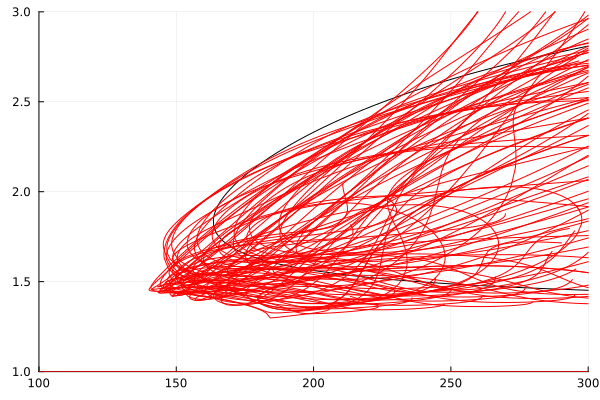

attempt to save state beyond implementation limit
print device already activated


In [63]:
α, γ = 1.1, 2.1
R=200

xguess = myreaddlm("/Users/samgeho/Desktop/TECH 412/xeq1-Re200-1-2-3.asc")
eq1ReD = myreaddlm("/Users/samgeho/Desktop/TECH 412/eq1ReD-DNS.asc", cc='#') #I put this in! Don't trust!

numTests = 0

my_vector = []
store = []
plotData = []
alpha_vector = []
gamma_vector = []
plot(eq1ReD[:,1], eq1ReD[:,2], color=:black, xlim = (125,300), ylim = (1,3), label="")
#plot(eq1ReD[:,1], eq1ReD[:,2], color=:black, label="eq DNS") I deleted label="eq DNS"

for i in 0:0.1:0.5
    #xguess = myreaddlm("/Users/samgeho/Desktop/TECH 412/xeq1projection-Re200-1-2-3-27d.asc")
    #eq1ReD = myreaddlm("/Users/samgeho/Desktop/TECH 412/eq1ReD-DNS.asc", cc='#') #I put this in! Don't trust!
    α -= 0.1
    γ = 2.1

    push!(alpha_vector, α)
    #@show a
    for j in 0:0.1:1
        try
            γ -= 0.1
            if α == 1.0
                push!(gamma_vector, γ)
            end
            J,K,L = 1,2,3  #1,2,3  #1,1,3       # Bounds on Fourier modes (J,K) and wall-normal polynomials (L)
            H = [sx*sy*sz, sz*tx*tz]            # Generators of the symmetric subspace of the Nagata eqb
            
            model = ODEModel(α, γ, J, K, L, H, normalize=true)  # Construct ODE model by Galerkin projection 
            
            #@show m = length(model)
            #@show x = length(xguess)
            @show norm(model.f(xguess, R));
            
            fr = x -> model.f(x,R)    # define function  f(x) = f(x,R)  for fixed R
            Dfr = x -> model.Df(x,R)  # define function Df(x) = Df(x,R) for fixed R
            
            @time xeq1, eq1success = hookstepsolve(fr, Dfr, xguess)

            println(norm(xeq1))
            
                
            @show norm(fr(xeq1))/norm(xeq1);
            
            shear(xeq1, model)
            
            myshear = x -> shear(x,model) ###one with fixed basis I=myshear(xeq1)
            I = myshear(xeq1)
            push!(plotData, [sqrt((2*pi/α)^2 + (2*pi/γ)^2), I])
            fp(x,p) = model.f(x,p[1])
            prob1 = BK.BifurcationProblem(fp,
                xeq1,         # initial condition x0
                [Float64(R)], # set of parameters
                1;            # parameter index for continuation
                #record_from_solution = (x,p; k...) -> shear(x),
                plot_solution = (x,p; k...) -> myshear(x),
                record_from_solution = (x,p; k...) -> myshear(x),
                )
            
            newtopts = BK.NewtonPar(1e-10, 25, false, BK.DefaultLS(), BK.DefaultEig(), false, 1.0, 0.01)
            contopts = BK.ContinuationPar(p_min = 0., p_max = 400., n_inversion=20, dsmin=1e-12, dsmax=1.0, 
                max_steps = 200, newton_options = newtopts)
                
            br1 = BK.continuation(prob1, BK.PALC(), contopts, bothside=true)
                
            #plot(br1)
            
            #push!(my_matrix, [R, α, γ, xguess])

            ReD1 = [br1.param br1.x];
            #xguess = xeq1
            if minimum(ReD1) > 1.1
                push!(my_vector, [minimum(ReD1[:,1])]) 
                xguess = xeq1
                push!(store, [α, γ, xeq1])
            else
                push!(my_vector, [0.0])
                push!(store, [α, γ, xguess])
            end

            #eq1ReD = ReD1 #I put this in! don't trust!

            eq1ReD = myreaddlm("/Users/samgeho/Desktop/TECH 412/eq1ReD-DNS.asc", cc='#') #uncomment if does not work
            #plot(eq1ReD[:,1], eq1ReD[:,2], color=:black, label="eq1 DNS")
            #plot!(ReD1[:,1], ReD1[:,2], color=:blue, xlim = (125,300), ylim = (1,3), label="")
            #plot!(ReD1[:,1], ReD1[:,2], color=:blue, label="eq1 ODE, K-(m)d")
            #plot!(ReD2[:,1], ReD2[:,2], color=:blue, label="")
            #plot!(xlabel="Re", ylabel="I", xlim=(150,300), ylim=(1,3)) 
            #push!(my_vector, [minimum(ReD1[:,1])])  
            #######
            #plot!(x, y, color=:green, label = "xxx")
            plot!(ReD1[:,1], ReD1[:,2], color=:red, xlim = (100,300), ylim = (1,3), label="")####### I'm still using this one!

            numTests += 1
        
        catch e
            println()
            println(e)
            println()
            numTests += 1
            push!(my_vector, [0.0])
            push!(store, [α, γ, xguess])
        end

    end
end
plot!(ReD1[:,1], ReD1[:,2], color=:red, xlim = (100,300), ylim = (1,3), label="")


#plot!()

#@show numTests
#@show my_vector
    

In [31]:
ReD1

356×2 Matrix{Float64}:
 359.222  1.39149
 357.808  1.39254
 356.394  1.39371
 354.979  1.39502
 353.565  1.39646
 352.151  1.39805
 350.737  1.39979
 349.323  1.4017
 347.908  1.40379
 346.494  1.40606
   ⋮      
 389.899  2.69589
 391.313  2.70131
 392.727  2.70672
 394.142  2.71212
 395.556  2.71751
 396.97   2.7229
 398.384  2.72827
 399.799  2.73365
 400.0    2.73441

In [64]:
@show my_vector
my_matrix = Matrix{Vector{Float64}}(reshape(my_vector, 11,:))
display(my_matrix)
#show store
#@show alpha_vector, gamma_vector
@show gamma_vector
#println("minimum alpha: ", minimum(alpha_vector), ", maximum alpha: ", maximum(alpha_vector), ", length of vector: ", length(alpha_vector))
#println("minimum gamma: ", minimum(gamma_vector), ", maximum gamma: ", maximum(gamma_vector), ", length of vector: ", length(gamma_vector))

11×6 Matrix{Vector{Float64}}:
 [175.627]  [176.628]  [187.422]  [0.0]      [0.0]      [0.0]
 [165.378]  [163.095]  [171.088]  [187.763]  [0.0]      [0.0]
 [159.038]  [153.982]  [157.574]  [170.802]  [193.628]  [0.0]
 [154.035]  [150.36]   [148.342]  [156.607]  [175.244]  [0.0]
 [149.704]  [148.665]  [146.366]  [146.557]  [159.972]  [185.193]
 [146.081]  [146.896]  [147.403]  [145.515]  [148.724]  [168.618]
 [143.198]  [145.265]  [147.618]  [149.944]  [145.279]  [156.043]
 [141.118]  [144.017]  [147.581]  [151.98]   [156.702]  [148.68]
 [140.092]  [143.369]  [147.734]  [153.368]  [160.686]  [168.972]
 [140.745]  [143.777]  [148.421]  [154.835]  [163.495]  [175.376]
 [144.174]  [146.28]   [150.333]  [156.874]  [166.312]  [179.757]

my_vector = Any[[175.6267701965032], [165.3780992640314], [159.03788433401166], [154.03474689432207], [149.70391035755594], [146.08087362928612], [143.19780598230798], [141.11781105792534], [140.09220518542372], [140.74463617670267], [144.17373857548088], [176.6279856341788], [163.09542835463162], [153.98189775736026], [150.36015682435394], [148.66543044129952], [146.89573808097586], [145.26478767647285], [144.01688344015525], [143.3686381310412], [143.77659848558974], [146.28002084342506], [187.4215927558639], [171.08787064742927], [157.57403992621434], [148.34196616727814], [146.36583707138462], [147.40305024117532], [147.61768005901774], [147.5812777987492], [147.73448019557432], [148.42134307901657], [150.33299356853706], [0.0], [187.76333047758982], [170.8015004270458], [156.60688031664415], [146.5568332494106], [145.51482930221744], [149.94392839102045], [151.98011633794775], [153.36831706760373], [154.83504363456245], [156.8742971520793], [0.0], [0.0], [193.62788712738814], [175

11-element Vector{Any}:
 2.0
 1.9
 1.7999999999999998
 1.6999999999999997
 1.5999999999999996
 1.4999999999999996
 1.3999999999999995
 1.2999999999999994
 1.1999999999999993
 1.0999999999999992
 0.9999999999999992

In [61]:
println(alpha_vector)
println(gamma_vector)

Any[1.0, 0.9, 0.8, 0.7000000000000001, 0.6000000000000001, 0.5000000000000001]
Any[2.0, 1.9, 1.7999999999999998, 1.6999999999999997, 1.5999999999999996, 1.4999999999999996, 1.3999999999999995, 1.2999999999999994, 1.1999999999999993, 1.0999999999999992, 0.9999999999999992, 2.0, 1.9, 1.7999999999999998, 1.6999999999999997, 1.5999999999999996, 1.4999999999999996, 1.3999999999999995, 1.2999999999999994, 1.1999999999999993, 1.0999999999999992, 0.9999999999999992, 2.0, 1.9, 1.7999999999999998, 1.6999999999999997, 1.5999999999999996, 1.4999999999999996, 1.3999999999999995, 1.2999999999999994, 1.1999999999999993, 1.0999999999999992, 0.9999999999999992, 2.0, 1.9, 1.7999999999999998, 1.6999999999999997, 1.5999999999999996, 1.4999999999999996, 1.3999999999999995, 1.2999999999999994, 1.1999999999999993, 1.0999999999999992, 0.9999999999999992, 2.0, 1.9, 1.7999999999999998, 1.6999999999999997, 1.5999999999999996, 1.4999999999999996, 1.3999999999999995, 1.2999999999999994, 1.1999999999999993, 1.09999

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
attempt to save state beyond implementation limit


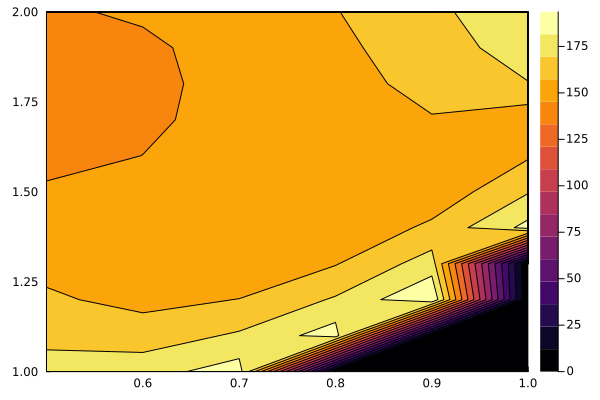

In [65]:
import Pkg; Pkg.add("PlotlyJS")
# 1. Define x and y
x = range(minimum(alpha_vector), maximum(alpha_vector), length(alpha_vector))
y = range(minimum(gamma_vector), maximum(gamma_vector), length(gamma_vector))

# 2. Define the matrix
Z = only.(my_matrix)

# 3. Create the contour plot
# Pass x, y, and the function f
contour(x, y, Z, fill=true) # 'fill=true' creates filled contours (contourf)
